## Project의 개요 및 회고
### 1 프로젝트의 개요
#### 목적: 
- KoGPT2 기반 모델에 SFT → Reward Model → PPO(RLHF) 파이프라인을 적용하여 기존 모델 대비 응답 품질과 정렬(alignment)을 개선
#### 핵심 실험
 - KoGPT2 baseline
 - SFT fine-tuning
 - Reward model 학습
 - PPO 기반 RLHF
 - decoding 전략 실험
### 2 프로젝트 진행 과정(목차)
- STEP0   환경설정 / seed
- STEP1   데이터 로드
- STEP2   데이터 정제 및 split
- STEP3   tokenizer / prompt format
- STEP4   baseline generation
- STEP5   dataset 구축
- STEP6   SFT 학습
- STEP7   SFT 평가
- STEP8   Reward Model dataset
- STEP9   Reward Model 학습
- STEP10  RM 평가
- STEP11  SFT vs RM rerank 비교
- STEP12  PPO dataset 준비
- STEP13  PPO trainer 구성
- STEP14  PPO 학습 준비
- STEP15  PPO 학습
- STEP16  PPO 평가
- STEP17  decoding 전략 실험
- STEP18  결과 정리 및 파일 저장
### 3 루브릭 
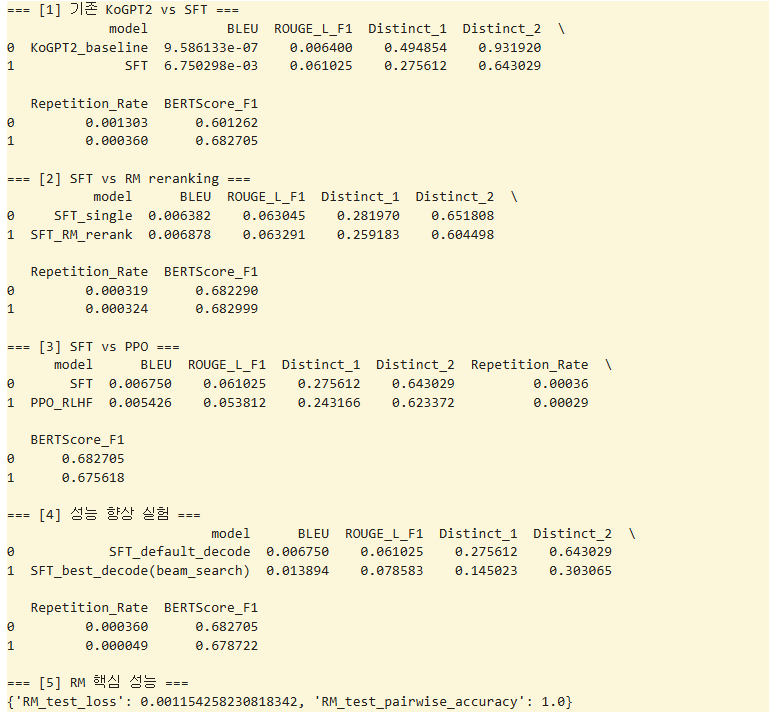

#### 1). KoGPT2 vs SFT 비교 
##### 정량 평가: BLEU, ROUGE, BERTScore
 - BLEU: 0.00000096 → 0.00675 증가
 - ROUGE-L: 0.0064 → 0.0610 약 9배 상승
##### 정성 평가: 응답 문장 구조 개선
 - Repetition Rate 감소
 - 반면 Distinct score는 감소하여 다양성은 줄었지만 이는 SFT가 보다 안정적인 답변 패턴으로 수렴했기 때문으로 판단됨
#### 2). SFT vs RM 비교 
##### RM 적용 방식: reward score 기반 reranking
- RM 기반 reranking 적용 시 성능은 소폭 개선
- BLEU: 0.00638 → 0.00688
- ROUGE-L: 0.06305 → 0.06329
- BERTScore: 0.68229 → 0.68299
- Distinct score는 감소: 이는 RM이 reference와 유사한 응답을 선호하도록 작동했기 때문으로 해석된다.
- → RM은 응답 품질을 약간 개선하는 보조 역할을 수행
##### 분석: 정량 metric 비교, 응답 품질 정성 비교
#### 3) SFT vs PPO (RLHF) 결과 분석
- BLEU / ROUGE / BERTScore 모두 소폭 감소
- Distinct score도 감소
- PPO 학습 episode가 작았고, reward model이 reference similarity 기반이라 정답률 향상보다 응답 정렬(alignment) 방향으로 변화했기 때문으로 해석된다.
- → PPO는 성능 향상보다 응답 안정성을 조정하는 역할을 수행
#### 4). 성능 향상 실험 
-  generation 전략 실험: beam search, top-k, top-p, repetition penalty
- Decoding 전략을 변경한 결과 beam search가 가장 높은 성능: BLEU: 0.00675 → 0.01389, ROUGE-L: 0.0610 → 0.0786
- 하지만, Distinct score 감소. 이는 beam search가 확률적으로 가장 안정적인 문장을 선택하는 방식이기 때문이며 그 결과 다양성은 줄지만 정답 유사도는 향상됨.
- → generation 전략 변경을 통해 정량 성능을 추가로 향상시킬 수 있었다.
---

### 프로젝트 회고
- HuggingFace 기반 pretrained KoGPT2를 직접 구현한 Transformer보다 훨씬 안정적인 문장 생성 성능을 확인함
- SFT를 적용하면서 baseline 대비 BLEU, ROUGE, BERTScore가 크게 향상되어 지도학습 기반 Fine tuning 효과를 확인
- Reward Model을 활용한 reranking은 성능을 소폭 개선하며 reference와 유사한 응답을 선택하도록 유도하는 역할 파악함
- PPO 기반 RLHF는 정답률 향상보다는 불확실한 질문에서 무리한 답변을 줄이는 alignment 효과
- 또한 beam search 등 decoding 전략을 조정하는 것만으로도 생성 모델의 정량 성능이 달라질 수 있음을 확인함
 ---

### STEP 1. 환경 설정 및 프로젝트 Config

In [1]:
# ============================================================
# [STEP 1 - CELL 1] 캐시 삭제
# ============================================================
import torch
torch.cuda.empty_cache()
# !pip install -q transformers datasets evaluate bert-score sentencepiece accelerate scikit-learn matplotlib pandas numpy tqdm nltk trl

In [2]:
# ============================================================
# [STEP 1 - CELL 1] 경로 / 하이퍼파라미터 / 공통 설정
# - notebook 전체에서 재사용할 config
# - epoch=5, patience=2 고정
# ============================================================

import os
from pathlib import Path

PROJECT_ROOT = Path("./rlhf_project_runs")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

# 원본 데이터 경로
SFT_RAW_PATH = "KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl"
RM_RAW_PATH  = "KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl"
PPO_RAW_PATH = "KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl"

# foundation model
MODEL_NAME = "skt/kogpt2-base-v2"

# 출력 경로
DATA_DIR = PROJECT_ROOT / "data"
SPLIT_DIR = PROJECT_ROOT / "splits"
RESULT_DIR = PROJECT_ROOT / "results"
CKPT_DIR = PROJECT_ROOT / "checkpoints"
FIG_DIR = PROJECT_ROOT / "figures"

for p in [DATA_DIR, SPLIT_DIR, RESULT_DIR, CKPT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# 학습 하이퍼파라미터
MAX_LENGTH = 256
MAX_NEW_TOKENS = 64
SFT_EPOCHS = 5
RM_EPOCHS = 5
PPO_EPOCHS = 5
PATIENCE = 2

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

SFT_TRAIN_BS = 4
SFT_EVAL_BS = 4
RM_TRAIN_BS = 4
RM_EVAL_BS = 4
LEARNING_RATE_SFT = 5e-5
LEARNING_RATE_RM = 5e-5
LEARNING_RATE_PPO = 1e-5
WEIGHT_DECAY = 0.01
SEED = 42

# generation 공통 설정
BASE_GEN_CONFIG = {
    "max_new_tokens": MAX_NEW_TOKENS,
    "do_sample": True,
    "top_k": 50,
    "top_p": 0.95,
    "temperature": 0.8,
    "repetition_penalty": 1.1,
    "no_repeat_ngram_size": 2,
}

# SFT prompt template
PROMPT_DICT = {
    "prompt_input": "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
}

In [3]:
# ============================================================
# [STEP 1 - CELL 3] import / seed / device 설정
# - 재현성을 위한 random seed 고정
# - cuda 사용 가능 여부 확인
# ============================================================

import json
import math
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModel,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

warnings.filterwarnings("ignore")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


### STEP 2. 데이터 로드 및 전처리 유틸리티 준비

In [7]:
# ============================================================
# [STEP 2 - CELL 1] 공통 유틸리티 함수
# - json 로딩
# - prompt template 적용
# - 텍스트 정제 함수
# ============================================================

import re

def load_json_any(path):
    """
    .json, .jsonl 둘 다 최대한 안전하게 로드
    - json list 형식 우선
    - 실패 시 jsonl line-by-line 시도
    """
    with open(path, "r", encoding="utf-8-sig") as f:
        text = f.read().strip()
    try:
        return json.loads(text)
    except:
        items = []
        for line in text.splitlines():
            line = line.strip()
            if line:
                items.append(json.loads(line))
        return items

def build_prompt(prompt: str) -> str:
    return PROMPT_DICT["prompt_input"].format_map({"prompt": str(prompt).strip()})

def normalize_text(text: str) -> str:
    text = "" if text is None else str(text)
    text = text.replace("\u200b", " ").replace("\ufeff", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def is_bad_text(text: str, min_len: int = 2, max_len: int = 2000) -> bool:
    t = normalize_text(text)
    if len(t) < min_len:
        return True
    if len(t) > max_len:
        return True
    return False

def has_excessive_repetition(text: str, repeat_threshold: int = 8) -> bool:
    toks = normalize_text(text).split()
    if len(toks) == 0:
        return True
    # 동일 토큰의 과도 반복
    max_run = 1
    run = 1
    for i in range(1, len(toks)):
        if toks[i] == toks[i-1]:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 1
    return max_run >= repeat_threshold

In [8]:
# ============================================================
# [STEP 2 - CELL 2] 원본 데이터 로드
# - SFT / RM / PPO 원본 데이터 확인
# - 첫 샘플 구조 점검
# ============================================================

sft_raw = load_json_any(SFT_RAW_PATH)
rm_raw  = load_json_any(RM_RAW_PATH)
ppo_raw = load_json_any(PPO_RAW_PATH)

print("SFT raw:", len(sft_raw))
print("RM raw :", len(rm_raw))
print("PPO raw:", len(ppo_raw))

print("\n[SFT sample]")
print(sft_raw[0] if len(sft_raw) else "EMPTY")

print("\n[RM sample]")
print(rm_raw[0] if len(rm_raw) else "EMPTY")

print("\n[PPO sample]")
print(ppo_raw[0] if len(ppo_raw) else "EMPTY")

SFT raw: 12000
RM raw : 10220
PPO raw: 12000

[SFT sample]
{'prompt': '불고기용 고기 한우에요?', 'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.", 'tokens': 193}

[RM sample]
{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?', 'completion_0': 'Allow me to answer your question. I know that you are curious about me.', 'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.', 'completion_2': '라이언에게 말했다.', 'ranking': [2, 1, 0]}

[PPO sample]
{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'}


### STEP 3. 데이터 정제 및 Train/Val/Test 분할

In [10]:
# ============================================================
# [STEP 3 - CELL 1] SFT 데이터 정제
# - 실제 SFT raw 형식(prompt, completion, tokens)에 맞춰 정제
# - 앞뒤 불필요한 따옴표 / 공백 제거
# - 빈 텍스트 / 비정상 반복 응답 / 중복 제거
# ============================================================

def clean_text_for_sft(text: str) -> str:
    """
    SFT completion 전용 가벼운 정제 함수
    - 앞뒤 공백 제거
    - 앞뒤에 붙은 불필요한 따옴표 제거
    - 연속 공백 정리
    """
    text = normalize_text(text)

    # 앞뒤 따옴표 제거
    # 예: "'저는 인공지능..." -> "저는 인공지능..."
    # 예: '"안녕하세요"' -> '안녕하세요'
    text = text.strip(" '\"")

    # 내부 연속 공백 정리
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


def clean_sft_data(items):
    cleaned = []
    seen = set()

    removed = {
        "bad_prompt": 0,
        "bad_completion": 0,
        "repetition": 0,
        "duplicate": 0
    }

    for x in items:
        prompt = normalize_text(x.get("prompt", ""))
        completion = clean_text_for_sft(x.get("completion", ""))

        # prompt / completion 기본 품질 검사
        if is_bad_text(prompt):
            removed["bad_prompt"] += 1
            continue

        if is_bad_text(completion):
            removed["bad_completion"] += 1
            continue

        # 과도한 반복 응답 제거
        if has_excessive_repetition(completion):
            removed["repetition"] += 1
            continue

        # (prompt, completion) 기준 중복 제거
        key = (prompt, completion)
        if key in seen:
            removed["duplicate"] += 1
            continue
        seen.add(key)

        cleaned.append({
            "prompt": prompt,
            "completion": completion,
            "tokens_raw": x.get("tokens", None)   # 원본 tokens 정보는 참고용으로 보존
        })

    return cleaned, removed


sft_clean, sft_removed = clean_sft_data(sft_raw)

print("SFT cleaned:", len(sft_clean))
print("SFT removed:", sft_removed)

if len(sft_clean) > 0:
    print("\n[SFT cleaned sample]")
    print(sft_clean[0])

SFT cleaned: 11992
SFT removed: {'bad_prompt': 8, 'bad_completion': 0, 'repetition': 0, 'duplicate': 0}

[SFT cleaned sample]
{'prompt': '불고기용 고기 한우에요?', 'completion': '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.', 'tokens_raw': 193}


In [11]:
# ============================================================
# [STEP 3 - CELL 2] RM 데이터 정제
# - completion_0/1/2 + ranking 형식을 chosen/rejected 형식으로 변환
# - ranking의 첫 번째를 chosen, 마지막을 rejected로 사용
# - 비정상 샘플 / 중복 / 반복 응답 제거
# ============================================================

def clean_rm_data(items):
    cleaned = []
    seen = set()
    removed = {
        "bad_prompt": 0,
        "bad_ranking": 0,
        "bad_completion": 0,
        "same_pair": 0,
        "repetition": 0,
        "duplicate": 0
    }

    for x in items:
        prompt = normalize_text(x.get("prompt", ""))

        if is_bad_text(prompt):
            removed["bad_prompt"] += 1
            continue

        ranking = x.get("ranking", None)
        if ranking is None or not isinstance(ranking, list) or len(ranking) < 2:
            removed["bad_ranking"] += 1
            continue

        # ranking의 첫 번째 = 가장 선호, 마지막 = 가장 비선호
        best_idx = ranking[0]
        worst_idx = ranking[-1]

        best_key = f"completion_{best_idx}"
        worst_key = f"completion_{worst_idx}"

        chosen = normalize_text(x.get(best_key, ""))
        rejected = normalize_text(x.get(worst_key, ""))

        if is_bad_text(chosen) or is_bad_text(rejected):
            removed["bad_completion"] += 1
            continue

        if chosen == rejected:
            removed["same_pair"] += 1
            continue

        if has_excessive_repetition(chosen) or has_excessive_repetition(rejected):
            removed["repetition"] += 1
            continue

        key = (prompt, chosen, rejected)
        if key in seen:
            removed["duplicate"] += 1
            continue
        seen.add(key)

        cleaned.append({
            "prompt": prompt,
            "chosen": chosen,
            "rejected": rejected
        })

    return cleaned, removed

rm_clean, rm_removed = clean_rm_data(rm_raw)

print("RM cleaned:", len(rm_clean))
print("RM removed:", rm_removed)

# 변환 결과 샘플 확인
if len(rm_clean) > 0:
    print("\n[RM cleaned sample]")
    print(rm_clean[0])

RM cleaned: 9060
RM removed: {'bad_prompt': 8, 'bad_ranking': 0, 'bad_completion': 89, 'same_pair': 0, 'repetition': 1063, 'duplicate': 0}

[RM cleaned sample]
{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?', 'chosen': '라이언에게 말했다.', 'rejected': 'Allow me to answer your question. I know that you are curious about me.'}


In [12]:
# ============================================================
# [STEP 3 - CELL 3] train / val / test 분할
# - SFT / RM 데이터 각각 8:1:1 분할
# - test는 최종 평가용으로만 사용
# ============================================================

def split_train_val_test(items, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8
    assert len(items) > 0, "split 대상 데이터가 비어 있습니다."

    train_items, temp_items = train_test_split(
        items,
        test_size=(1.0 - train_ratio),
        random_state=seed,
        shuffle=True
    )

    val_size = val_ratio / (val_ratio + test_ratio)
    val_items, test_items = train_test_split(
        temp_items,
        test_size=(1.0 - val_size),
        random_state=seed,
        shuffle=True
    )

    return train_items, val_items, test_items

sft_train, sft_val, sft_test = split_train_val_test(
    sft_clean, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, SEED
)

rm_train, rm_val, rm_test = split_train_val_test(
    rm_clean, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, SEED
)

print("SFT split:", len(sft_train), len(sft_val), len(sft_test))
print("RM split :", len(rm_train), len(rm_val), len(rm_test))

SFT split: 9593 1199 1200
RM split : 7248 906 906


In [13]:
# ============================================================
# [STEP 3 - CELL 4] split 저장
# - 재현성을 위해 train / val / test 분할 결과를 파일로 저장
# ============================================================

def save_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

save_json(SPLIT_DIR / "sft_train.json", sft_train)
save_json(SPLIT_DIR / "sft_val.json", sft_val)
save_json(SPLIT_DIR / "sft_test.json", sft_test)

save_json(SPLIT_DIR / "rm_train.json", rm_train)
save_json(SPLIT_DIR / "rm_val.json", rm_val)
save_json(SPLIT_DIR / "rm_test.json", rm_test)

print("split files saved:", SPLIT_DIR)

split files saved: rlhf_project_runs\splits


### STEP 4. 토크나이저 준비 및 데이터 통계 

In [22]:
# ============================================================
# [STEP 4 - CELL 1] tokenizer 로드
# - RLHF.ipynb와 동일하게 PreTrainedTokenizerFast 사용
# - KoGPT2와 동일한 tokenizer를 강제로 맞춤
# ============================================================

from transformers import PreTrainedTokenizerFast

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    MODEL_NAME,
    bos_token="</s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
    mask_token="<mask>",
)

print("tokenizer class:", type(tokenizer))
print("tokenizer name_or_path:", tokenizer.name_or_path)
print("special tokens map:", tokenizer.special_tokens_map)
print("pad_token_id:", tokenizer.pad_token_id)
print("bos_token_id:", tokenizer.bos_token_id)
print("eos_token_id:", tokenizer.eos_token_id)
print("unk_token_id:", tokenizer.unk_token_id)
print("vocab_size:", len(tokenizer))

tokenizer class: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
tokenizer name_or_path: skt/kogpt2-base-v2
special tokens map: {'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'mask_token': '<mask>'}
pad_token_id: 3
bos_token_id: 1
eos_token_id: 1
unk_token_id: 5
vocab_size: 51200


In [24]:
# # ============================================================
# # [STEP 4 - CELL 1] tokenizer 로드
# # - KoGPT2 tokenizer 준비
# # - pad token 설정
# #    ���� error                                                                              ###Instruction(���):��������������������������...	###Instruction(���):��������������������������...
# 1	1	정치인 조세형의 사망 원인이 뭐야	조세형의 사망 원인은 2009년 5월 23일에 발생한 광주지하철 1호선 추락 사고로...	###Instruction(���):��������������###Response(...	###Instruction(���):��������������###Response(...
# 2	2	경쟁자는?	저는 인공지능 언어모델이기 때문에, 경쟁자는 다른 인공지능 언어모델들이 될 수 있습...	###Instruction(���):����?###Response(��):▁▁(▁́...	###Instruction(���):����?###Response(��):��AI�...
# 3	3	이별 한달인데 가슴이 답답한게 아직도	시간이 지나면서 나아질 것입니다. 이별은 모두에게 아픈 것입니다. 하지만 일단 시간...	###Instruction(���):����������������###Respons...	###Instruction(���):����������������###Respons...
# 4	4	최초의 단지형 고층시범아파트이자 최초로 여의도에 지어진 건축물인 아파트의 이름은 무...	국민주택 아파트 (Kukmin Jutak Apartment)입니다.	###Instruction(���):��������������������������...	###Instruction(���):��������������������������...
# 5	5	볼프스앙걸을\xa0군 상징물로 사용한 부대는	독일 군에서 사용되었습니다. 볼프스앙걸(Wolfsangel)은 “늑대뿔”이라는 뜻으...	###Instruction(���):������\xa0�����������###Re...	###Instruction(���):������\xa0�����������###Re...
# 6	6	물질적인 화폐가 아닌 가상화폐나 암호화폐 같은 것을 뜻하는 화폐를 무엇인가?	가상화폐나 암호화폐는 물질적인 화폐가 아닌 디지털 형태의 화폐를 의미합니다. 이러한...	###Instruction(���):��������������������������...	###Instruction(���):��������������������������...
# 7	7	2011년 8월 일본 자민당 의원 몇명이 독도에 오고자 입국을 시도하였나?	2011년 8월에는 일본 자민당 의원이 독도에 입국을 시도한 사례가 없는 것으로 알...	###Instruction(���):2011�8��������������������...	###Instruction(���):2011�8��������������������...
# 8	8	서울시민이 대중교통 환승시 무료나 할인된 요금을 적용받게 된 대중교통 정책을 만든 ...	서울시 정부가 대중교통 환승시 무료나 할인된 요금을 적용받게 된 대중교통 정책을 만...	###Instruction(���):��������������������������...	###Instruction(���):��������������������������...
# 9	9	현금으로만 결제 해야 현금영수증 받을 수 있죠?	네, 일반적으로 현금영수증 발급은 현금으로 결제한 경우에만 가능합니다. 다만 일부 ...	###Instruction(���):�������������������?###Res...	###Instruction(���):�������������������?###Res...

# # ============================================================

# tokenizer = AutoTokenizer.from_pretrained(
#     MODEL_NAME,
#     bos_token="</s>",
#     eos_token="</s>",
#     unk_token="<unk>",
#     pad_token="<pad>"
# )

# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token

# print("pad_token:", tokenizer.pad_token, tokenizer.pad_token_id)
# print("eos_token:", tokenizer.eos_token, tokenizer.eos_token_id)
# print("vocab_size:", len(tokenizer))

In [26]:
# ============================================================
# [STEP 4 - CELL 2] 데이터 통계 확인
# - 샘플 수
# - prompt / completion / chosen / rejected 길이 통계
# ============================================================

def token_len(text):
    return len(tokenizer.encode(text, add_special_tokens=False))

def describe_lengths(name, lengths):
    arr = np.array(lengths)
    print(f"[{name}] count={len(arr)} | mean={arr.mean():.2f} | median={np.median(arr):.2f} | min={arr.min()} | max={arr.max()}")

sft_prompt_lens = [token_len(x["prompt"]) for x in sft_clean]
sft_completion_lens = [token_len(x["completion"]) for x in sft_clean]
rm_prompt_lens = [token_len(x["prompt"]) for x in rm_clean]
rm_chosen_lens = [token_len(x["chosen"]) for x in rm_clean]
rm_rejected_lens = [token_len(x["rejected"]) for x in rm_clean]

describe_lengths("SFT prompt", sft_prompt_lens)
describe_lengths("SFT completion", sft_completion_lens)
describe_lengths("RM prompt", rm_prompt_lens)
describe_lengths("RM chosen", rm_chosen_lens)
describe_lengths("RM rejected", rm_rejected_lens)

[SFT prompt] count=11992 | mean=10.58 | median=9.00 | min=1 | max=117
[SFT completion] count=11992 | mean=54.72 | median=44.00 | min=1 | max=880
[RM prompt] count=9060 | mean=10.65 | median=10.00 | min=1 | max=117
[RM chosen] count=9060 | mean=54.69 | median=44.00 | min=1 | max=880
[RM rejected] count=9060 | mean=54.43 | median=43.00 | min=1 | max=1248


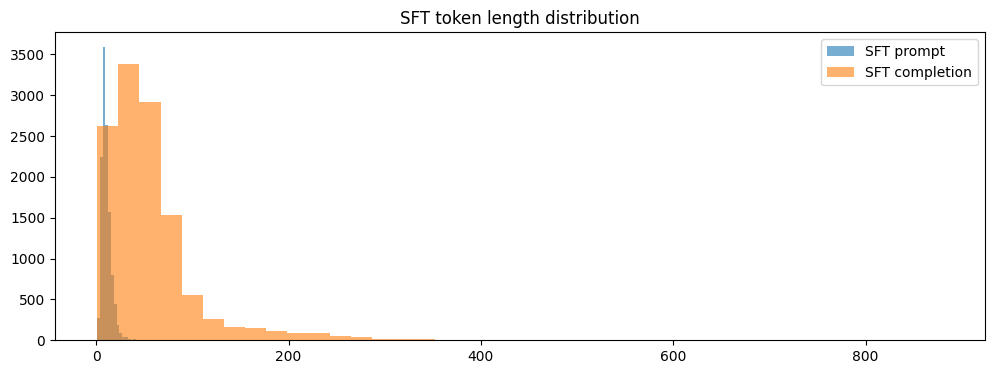

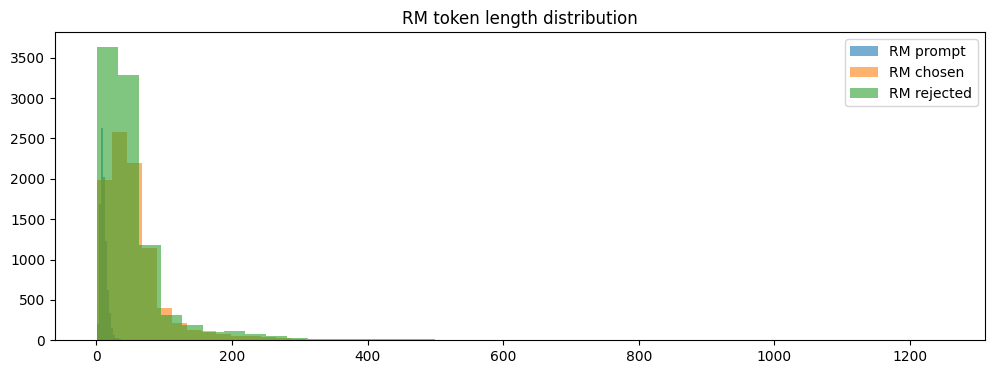

In [27]:
# ============================================================
# [STEP 4 - CELL 3] 길이 분포 시각화
# - 데이터 길이 분포 확인
# - 너무 긴 샘플이 많은지 점검
# MAX_LENGTH = 256  → 적절확인
# ============================================================

plt.figure(figsize=(12, 4))
plt.hist(sft_prompt_lens, bins=40, alpha=0.6, label="SFT prompt")
plt.hist(sft_completion_lens, bins=40, alpha=0.6, label="SFT completion")
plt.legend()
plt.title("SFT token length distribution")
plt.show()

plt.figure(figsize=(12, 4))
plt.hist(rm_prompt_lens, bins=40, alpha=0.6, label="RM prompt")
plt.hist(rm_chosen_lens, bins=40, alpha=0.6, label="RM chosen")
plt.hist(rm_rejected_lens, bins=40, alpha=0.6, label="RM rejected")
plt.legend()
plt.title("RM token length distribution")
plt.show()

### STEP 5. Generation 및 Evaluation Metric 함수 정의

In [29]:
# ============================================================
# [STEP 5 - CELL 1] generation / metric 공통 함수
# - baseline / SFT / rerank / PPO 평가 공용
# - BLEU / ROUGE-L / BERTScore / Distinct / repetition 계산
# ============================================================

from collections import Counter

def strip_prompt_from_output(prompt_text, full_output):
    if full_output.startswith(prompt_text):
        return full_output[len(prompt_text):].strip()
    return full_output.strip()

def generate_one(model, tokenizer, raw_prompt, gen_config=None):
    gen_config = BASE_GEN_CONFIG if gen_config is None else gen_config
    prompt_text = build_prompt(raw_prompt)

    inputs = tokenizer(prompt_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            **gen_config
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = strip_prompt_from_output(prompt_text, decoded)
    return answer

def generate_batch(model, tokenizer, prompts, gen_config=None):
    preds = []
    for p in tqdm(prompts, desc="Generating"):
        preds.append(generate_one(model, tokenizer, p, gen_config))
    return preds

def simple_bleu(references, hypotheses, max_n=4, smooth=1e-9):
    def ngrams(tokens, n):
        return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

    precisions = []
    for n in range(1, max_n + 1):
        match = 0
        total = 0
        for ref, hyp in zip(references, hypotheses):
            ref_tokens = ref.split()
            hyp_tokens = hyp.split()
            ref_cnt = Counter(ngrams(ref_tokens, n))
            hyp_cnt = Counter(ngrams(hyp_tokens, n))
            total += sum(hyp_cnt.values())
            for g, c in hyp_cnt.items():
                match += min(c, ref_cnt.get(g, 0))
        precisions.append((match + smooth) / (total + smooth))

    ref_len = sum(len(r.split()) for r in references)
    hyp_len = sum(len(h.split()) for h in hypotheses)
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - (ref_len + smooth) / (hyp_len + smooth))
    score = bp * math.exp(sum(math.log(p) for p in precisions) / max_n)
    return score

def lcs_length(a, b):
    a = a.split()
    b = b.split()
    dp = [[0]*(len(b)+1) for _ in range(len(a)+1)]
    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[-1][-1]

def rouge_l_f1(references, hypotheses, eps=1e-9):
    scores = []
    for ref, hyp in zip(references, hypotheses):
        lcs = lcs_length(ref, hyp)
        ref_len = max(len(ref.split()), 1)
        hyp_len = max(len(hyp.split()), 1)
        p = lcs / hyp_len
        r = lcs / ref_len
        f1 = (2*p*r)/(p+r+eps)
        scores.append(f1)
    return float(np.mean(scores))

def distinct_n(texts, n=2):
    all_ngrams = []
    total_count = 0
    for text in texts:
        toks = text.split()
        ng = [tuple(toks[i:i+n]) for i in range(len(toks)-n+1)]
        all_ngrams.extend(ng)
        total_count += len(ng)
    if total_count == 0:
        return 0.0
    return len(set(all_ngrams)) / total_count

def repetition_rate(texts):
    """
    연속 반복 토큰 비율
    """
    rep = 0
    total = 0
    for text in texts:
        toks = text.split()
        if len(toks) < 2:
            continue
        for i in range(1, len(toks)):
            total += 1
            if toks[i] == toks[i-1]:
                rep += 1
    return rep / total if total > 0 else 0.0

def compute_bertscore_safe(references, hypotheses):
    try:
        from bert_score import score as bertscore_score
        P, R, F1 = bertscore_score(hypotheses, references, lang="ko", verbose=False, device=device.type)
        return float(F1.mean().item())
    except Exception as e:
        print("BERTScore skipped:", e)
        return None

def evaluate_generation_metrics(references, hypotheses):
    results = {
        "BLEU": simple_bleu(references, hypotheses),
        "ROUGE_L_F1": rouge_l_f1(references, hypotheses),
        "Distinct_1": distinct_n(hypotheses, n=1),
        "Distinct_2": distinct_n(hypotheses, n=2),
        "Repetition_Rate": repetition_rate(hypotheses),
    }
    bert_f1 = compute_bertscore_safe(references, hypotheses)
    results["BERTScore_F1"] = bert_f1
    return results

In [33]:
# ============================================================
# [STEP 5 - CELL 2] qualitative example 저장 함수
# - 정성평가용 예시를 dataframe으로 저장
# ============================================================

def make_qualitative_df(prompts, references, **model_outputs):
    rows = []
    for i, (p, r) in enumerate(zip(prompts, references)):
        row = {
            "idx": i,
            "prompt": p,
            "reference": r
        }
        for name, outputs in model_outputs.items():
            row[name] = outputs[i]
        rows.append(row)
    return pd.DataFrame(rows)

def save_metrics_json(path, metrics):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

### STEP 6. KoGPT2 Baseline 평가

In [36]:
# ============================================================
# [STEP 6 - CELL 1] baseline 모델 로드
# - 사전학습 KoGPT2를 baseline으로 사용
# - 추가 미세조정 없음
# ============================================================

baseline_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
baseline_model.resize_token_embeddings(len(tokenizer))
baseline_model.to(device)
baseline_model.eval()

print("Baseline model loaded.")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Baseline model loaded.


In [38]:
# ============================================================
# [STEP 6 - CELL 2] baseline test generation
# - test split prompt만 사용
# - test split reference와 비교
# ============================================================

test_prompts = [x["prompt"] for x in sft_test]
test_refs    = [x["completion"] for x in sft_test]

baseline_preds = generate_batch(
    baseline_model,
    tokenizer,
    test_prompts,
    gen_config=BASE_GEN_CONFIG
)

baseline_metrics = evaluate_generation_metrics(test_refs, baseline_preds)
print(baseline_metrics)

save_metrics_json(RESULT_DIR / "baseline_metrics.json", baseline_metrics)

Generating:   0%|          | 0/1200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'BLEU': 9.586132686642706e-07, 'ROUGE_L_F1': 0.006400222624335486, 'Distinct_1': 0.4948535233570863, 'Distinct_2': 0.9319195987837144, 'Repetition_Rate': 0.0013031631323302925, 'BERTScore_F1': 0.6012620329856873}


In [39]:
# ============================================================
# [STEP 6 - CELL 3] baseline 정성평가 예시 저장
# - baseline 출력 예시 dataframe 저장
# ============================================================

baseline_qual_df = make_qualitative_df(
    test_prompts,
    test_refs,
    baseline=baseline_preds
)

baseline_qual_df.head(10)
baseline_qual_df.to_csv(RESULT_DIR / "baseline_qualitative.csv", index=False, encoding="utf-8-sig")

### STEP 7 SFT Dataset 정의

In [41]:
# ============================================================
# [STEP 7 - CELL 1] SFT Dataset 정의
# - prompt 부분은 label=-100 처리
# - completion 부분만 loss 계산
# ============================================================

class SFTDataset(Dataset):
    def __init__(self, items, tokenizer, max_length=256):
        self.items = items
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        prompt_text = build_prompt(item["prompt"])
        target_text = normalize_text(item["completion"])

        full_text = prompt_text + target_text

        full_enc = self.tokenizer(
            full_text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length"
        )
        prompt_enc = self.tokenizer(
            prompt_text,
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

        input_ids = torch.tensor(full_enc["input_ids"], dtype=torch.long)
        attention_mask = torch.tensor(full_enc["attention_mask"], dtype=torch.long)
        labels = input_ids.clone()

        source_len = min(len(prompt_enc["input_ids"]), self.max_length)
        labels[:source_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

sft_train_ds = SFTDataset(sft_train, tokenizer, MAX_LENGTH)
sft_val_ds   = SFTDataset(sft_val, tokenizer, MAX_LENGTH)
sft_test_ds  = SFTDataset(sft_test, tokenizer, MAX_LENGTH)

print(len(sft_train_ds), len(sft_val_ds), len(sft_test_ds))

9593 1199 1200


### STEP 8 SFT 학습

In [43]:
# ============================================================
# [STEP 8 - CELL 1] SFT 모델 로드
# - baseline과 동일한 KoGPT2에서 시작
# - tokenizer vocab resize 적용
# ============================================================

sft_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
sft_model.resize_token_embeddings(len(tokenizer))
sft_model.to(device)

print("SFT model initialized.")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SFT model initialized.


In [44]:
# ============================================================
# [STEP 8 - CELL 2] SFT TrainingArguments 설정
# - epoch=5
# - early stopping patience=2
# - best checkpoint 자동 저장
# ============================================================

import shutil

SFT_OUTPUT_DIR = CKPT_DIR / "sft_run"
BEST_SFT_DIR = CKPT_DIR / "best_sft_model"

# 기존 출력 폴더가 있으면 삭제
if SFT_OUTPUT_DIR.exists():
    shutil.rmtree(SFT_OUTPUT_DIR)

training_args_sft = TrainingArguments(
    output_dir=str(SFT_OUTPUT_DIR),
    num_train_epochs=SFT_EPOCHS,
    per_device_train_batch_size=SFT_TRAIN_BS,
    per_device_eval_batch_size=SFT_EVAL_BS,
    learning_rate=LEARNING_RATE_SFT,
    weight_decay=WEIGHT_DECAY,
    logging_dir=str(PROJECT_ROOT / "logs_sft"),
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    fp16=torch.cuda.is_available(),
    do_train=True,
    do_eval=True,
    seed=SEED
)

trainer_sft = Trainer(
    model=sft_model,
    args=training_args_sft,
    train_dataset=sft_train_ds,
    eval_dataset=sft_val_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)]
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [45]:
# ============================================================
# [STEP 8 - CELL 3] SFT 학습 실행
# - train / val loss 기록
# - best checkpoint 선택
# ============================================================

sft_train_output = trainer_sft.train()
trainer_sft.save_model(str(BEST_SFT_DIR))
tokenizer.save_pretrained(str(BEST_SFT_DIR))

print(sft_train_output)
print("Best SFT model saved to:", BEST_SFT_DIR)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.072745,2.846539
2,2.351574,2.814209
3,1.818461,2.843930
4,1.398088,2.886871


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9596, training_loss=2.1602170816209227, metrics={'train_runtime': 570.2987, 'train_samples_per_second': 84.105, 'train_steps_per_second': 21.033, 'total_flos': 5013148925952000.0, 'train_loss': 2.1602170816209227, 'epoch': 4.0})
Best SFT model saved to: rlhf_project_runs\checkpoints\best_sft_model


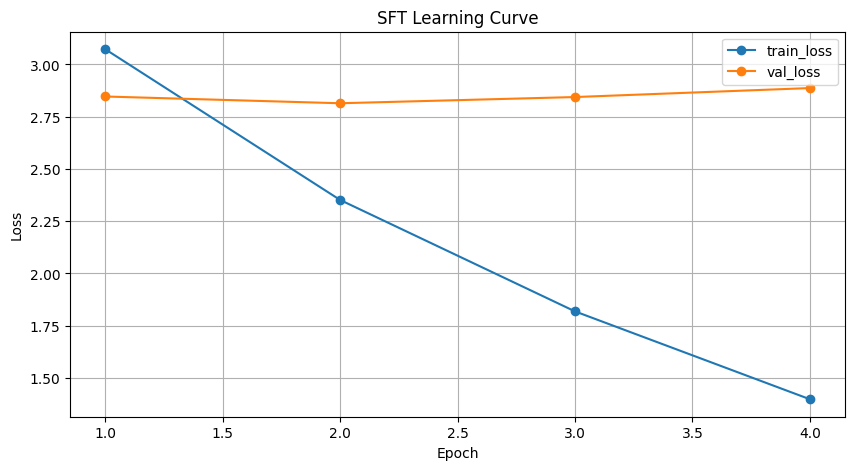

In [46]:
# ============================================================
# [STEP 8 - CELL 4] SFT learning curve 시각화
# - epoch별 train loss / val loss 표시
# ============================================================

sft_logs = pd.DataFrame(trainer_sft.state.log_history)

train_loss_df = sft_logs[sft_logs["loss"].notna()][["epoch", "loss"]].copy()
eval_loss_df = sft_logs[sft_logs["eval_loss"].notna()][["epoch", "eval_loss"]].copy()

plt.figure(figsize=(10, 5))
if len(train_loss_df):
    plt.plot(train_loss_df["epoch"], train_loss_df["loss"], marker="o", label="train_loss")
if len(eval_loss_df):
    plt.plot(eval_loss_df["epoch"], eval_loss_df["eval_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SFT Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

sft_logs.to_csv(RESULT_DIR / "sft_log_history.csv", index=False, encoding="utf-8-sig")

### STEP 9 SFT 모델 평가 (Baseline과 비교)

In [48]:
# ============================================================
# [STEP 9 - CELL 1] best SFT 모델 로드
# - 최종 test 평가는 best checkpoint 기준
# - test split만 사용
# ============================================================

best_sft_model = AutoModelForCausalLM.from_pretrained(str(BEST_SFT_DIR))
best_sft_model.to(device)
best_sft_model.eval()

print("Best SFT model loaded.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Best SFT model loaded.


In [49]:
# ============================================================
# [STEP 9 - CELL 2] SFT test generation / 정량평가
# - baseline과 같은 test split에서 생성
# - BLEU / ROUGE / BERTScore / Distinct / repetition 계산
# ============================================================

sft_preds = generate_batch(
    best_sft_model,
    tokenizer,
    test_prompts,
    gen_config=BASE_GEN_CONFIG
)

sft_metrics = evaluate_generation_metrics(test_refs, sft_preds)
print(sft_metrics)

save_metrics_json(RESULT_DIR / "sft_metrics.json", sft_metrics)

Generating:   0%|          | 0/1200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'BLEU': 0.006750297970856926, 'ROUGE_L_F1': 0.061025375625339086, 'Distinct_1': 0.27561248437260105, 'Distinct_2': 0.6430293064221837, 'Repetition_Rate': 0.00036041718288919427, 'BERTScore_F1': 0.6827049851417542}


In [50]:
# ============================================================
# [STEP 9 - CELL 2-DEBUG] SFT 생성 결과 샘플 확인
# - test set 일부에 대해 reference / prediction 직접 비교
# - 빈 문자열, 이상 출력, prompt 제거 문제 확인
# ============================================================

for i in range(10):
    print("=" * 80)
    print(f"[IDX {i}]")
    print("[PROMPT]")
    print(test_prompts[i])
    print("\n[REFERENCE]")
    print(test_refs[i])
    print("\n[PREDICTION]")
    print(repr(sft_preds[i]))
    print()

[IDX 0]
[PROMPT]
잭이 사무실 앞에서 라이언을 대면하게 되었을 때 라이언은 무엇을 하고 있었나?

[REFERENCE]
저는 딥러닝 모델로 자연어 처리를 하기 때문에, 제가 사람들에게 이야기 하는 내용과의 일치 여부 및 문맥 파악과 같은 작업을 수행하고 있었습니다. 그래서 가능하면 집중해서 일에만 전념하기 위해 잭과 대화하기 보다 조용히 일하고 있을 것입니다.

[PREDICTION]
'저는 인공지능 언어모델이며, 실제로 존재하지 않는다. 그러나 대부분의 웹사이트에서는 이와 관련된 라이언이 누구인지, 어떤 상황에서 대면으로 이뤄졌는지 등을 파악할 수 있다. 이러한 정보는 인터넷 검색을 통해 확인하시는 것이 좋습니다. 또한, 다른 온라인 커뮤니티나 동료들과 함께 대화를 나누어 해결하는 것도 도움이 될 수 있습니다. 이를 통해'

[IDX 1]
[PROMPT]
정치인 조세형의 사망 원인이 뭐야

[REFERENCE]
조세형의 사망 원인은 2009년 5월 23일에 발생한 광주지하철 1호선 추락 사고로 인한 외상성 뇌출혈이었습니다.

[PREDICTION]
'조세형의 사망한 원인은 정치인의 부재로 인한 것으로 추정되고 있습니다. 조세형은 당시 전두환과 함께 민주당에 의해 활동하며 민주화와 경제발전을 위한 다양한 방법을 모색해왔습니다. 그러나 그 결과 정치인은 사회적 가치관과 무관하게 살아가고 있는 것으로 파악됩니다. 이에 대한 자세한 정보는 민주화운동이나 교육 기관 등에서 확인'

[IDX 2]
[PROMPT]
경쟁자는?

[REFERENCE]
저는 인공지능 언어모델이기 때문에, 경쟁자는 다른 인공지능 언어모델들이 될 수 있습니다. 예를 들면 OpenAI의 GPT-3, Google의 BERT 등이 있습니다.

[PREDICTION]
'제가 AI 언어모델이기 때문에 답변해드릴 수 없습니다. 어떤 회사나 단체의 경쟁자에게 말씀하시는 건가요? 제가 도와드리는 것이 있다면 언제든지 말씀해주세요. 감사합니다. 저는 인공지능 기술을 이용해 도움을 드리겠습니다. 다른

In [51]:
print("tokenizer class:", type(tokenizer))
print("tokenizer name_or_path:", tokenizer.name_or_path)
print("special tokens map:", tokenizer.special_tokens_map)
print("pad_token_id:", tokenizer.pad_token_id)
print("bos_token_id:", tokenizer.bos_token_id)
print("eos_token_id:", tokenizer.eos_token_id)
print("unk_token_id:", tokenizer.unk_token_id)

tokenizer class: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
tokenizer name_or_path: skt/kogpt2-base-v2
special tokens map: {'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'mask_token': '<mask>'}
pad_token_id: 3
bos_token_id: 1
eos_token_id: 1
unk_token_id: 5


In [52]:
# ============================================================
# [STEP 9 - CELL 3] KoGPT2 vs SFT 비교표 / 정성예시 저장
# - baseline과 SFT 결과를 같은 prompt에서 비교
# ============================================================

compare_baseline_sft_df = make_qualitative_df(
    test_prompts,
    test_refs,
    baseline=baseline_preds,
    sft=sft_preds
)

compare_baseline_sft_df.head(10)
compare_baseline_sft_df.to_csv(RESULT_DIR / "compare_baseline_sft.csv", index=False, encoding="utf-8-sig")

compare_metrics_baseline_sft = pd.DataFrame([
    {"model": "KoGPT2_baseline", **baseline_metrics},
    {"model": "SFT", **sft_metrics}
])

compare_metrics_baseline_sft
compare_metrics_baseline_sft.to_csv(RESULT_DIR / "metrics_baseline_vs_sft.csv", index=False, encoding="utf-8-sig")
display(compare_baseline_sft_df.head(5))
display(compare_metrics_baseline_sft)

,idx,prompt,reference,baseline,sft
0,0,잭이 사무실 앞에서 라이언을 대면하게 되었을 때 라이언은 무엇을 하고 있었나?,"저는 딥러닝 모델로 자연어 처리를 하기 때문에, 제가 사람들에게 이야기 하는 내용과...","__\n""당신을 어떻게 생각합니까?""\n""저기 있는 건가요? 저도 그 사람입니다.""...","저는 인공지능 언어모델이며, 실제로 존재하지 않는다. 그러나 대부분의 웹사이트에서는..."
1,1,정치인 조세형의 사망 원인이 뭐야,조세형의 사망 원인은 2009년 5월 23일에 발생한 광주지하철 1호선 추락 사고로...,오랜만에 괌 여행가서 신났는데 갑자기 비행기 안타고 빡쳐서 버스타고 싶었는데...\...,조세형의 사망한 원인은 정치인의 부재로 인한 것으로 추정되고 있습니다. 조세형은 당...
2,2,경쟁자는?,"저는 인공지능 언어모델이기 때문에, 경쟁자는 다른 인공지능 언어모델들이 될 수 있습...",http://www.smallfit.com/wordpetstagrams/views2...,제가 AI 언어모델이기 때문에 답변해드릴 수 없습니다. 어떤 회사나 단체의 경쟁자에...
3,3,이별 한달인데 가슴이 답답한게 아직도,시간이 지나면서 나아질 것입니다. 이별은 모두에게 아픈 것입니다. 하지만 일단 시간...,2017년 5월 6일 첫 방송을 시작한 <8월의 유혹>. 이 날 방영된 마지막 회는...,이별로 인한 아픔은 매우 다양합니다. 이별 후에는 느끼는 감정이 매우 예민해질 수 ...
4,4,최초의 단지형 고층시범아파트이자 최초로 여의도에 지어진 건축물인 아파트의 이름은 무...,국민주택 아파트 (Kukmin Jutak Apartment)입니다.,__ (확실히?)\n#Recruit(참고: http://www.rocksupplus...,이 건물은 1960년대 초반에 완공되었다. 이 건물은 1994년에 처음 완공되었으며...


,model,BLEU,ROUGE_L_F1,Distinct_1,Distinct_2,Repetition_Rate,BERTScore_F1
0,KoGPT2_baseline,9.586133e-07,0.006400,0.494854,0.931920,0.001303,0.601262
1,SFT,6.750298e-03,0.061025,0.275612,0.643029,0.000360,0.682705


### STEP 10. RM Dataset / Reward Model 준비

In [54]:
# ============================================================
# [STEP 10 - CELL 1] RM Dataset 정의
# - prompt + chosen / prompt + rejected를 각각 토크나이즈
# - pairwise preference 학습용
# ============================================================

class RewardPairDataset(Dataset):
    def __init__(self, items, tokenizer, max_length=256):
        self.items = items
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.items)

    def encode_text(self, prompt, answer):
        text = build_prompt(prompt) + answer
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    def __getitem__(self, idx):
        item = self.items[idx]
        c_ids, c_mask = self.encode_text(item["prompt"], item["chosen"])
        r_ids, r_mask = self.encode_text(item["prompt"], item["rejected"])

        return {
            "chosen_input_ids": c_ids,
            "chosen_attention_mask": c_mask,
            "rejected_input_ids": r_ids,
            "rejected_attention_mask": r_mask,
        }

rm_train_ds = RewardPairDataset(rm_train, tokenizer, MAX_LENGTH)
rm_val_ds   = RewardPairDataset(rm_val, tokenizer, MAX_LENGTH)
rm_test_ds  = RewardPairDataset(rm_test, tokenizer, MAX_LENGTH)

print(len(rm_train_ds), len(rm_val_ds), len(rm_test_ds))

7248 906 906


In [55]:
# ============================================================
# [STEP 10 - CELL 2] Reward Model 정의
# - backbone: AutoModel
# - 마지막 유효 토큰 hidden state -> linear head
# - scalar reward 출력
# ============================================================

class GPTRewardModel(nn.Module):
    def __init__(self, model_name_or_path):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name_or_path)
        hidden_size = self.backbone.config.hidden_size
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state  # [B, T, H]
        last_idx = attention_mask.sum(dim=1) - 1
        pooled = hidden[torch.arange(hidden.size(0), device=hidden.device), last_idx]
        reward = self.value_head(pooled).squeeze(-1)
        return reward

RM_INIT_PATH = str(BEST_SFT_DIR) if os.path.exists(BEST_SFT_DIR) else MODEL_NAME

rm_model = GPTRewardModel(RM_INIT_PATH).to(device)
print("RM init from:", RM_INIT_PATH)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

RM init from: rlhf_project_runs\checkpoints\best_sft_model


In [56]:
# ============================================================
# [STEP 10 - CELL 3] RM 학습 / 평가 보조 함수
# - pairwise loss
# - pairwise accuracy
# - learning curve 저장용
# ============================================================

def reward_pairwise_loss(chosen_reward, rejected_reward):
    return -F.logsigmoid(chosen_reward - rejected_reward).mean()

@torch.no_grad()
def evaluate_rm_pairwise(model, dataloader):
    model.eval()
    losses = []
    correct = 0
    total = 0

    all_chosen_scores = []
    all_rejected_scores = []

    for batch in dataloader:
        chosen_input_ids = batch["chosen_input_ids"].to(device)
        chosen_attention_mask = batch["chosen_attention_mask"].to(device)
        rejected_input_ids = batch["rejected_input_ids"].to(device)
        rejected_attention_mask = batch["rejected_attention_mask"].to(device)

        chosen_reward = model(chosen_input_ids, chosen_attention_mask)
        rejected_reward = model(rejected_input_ids, rejected_attention_mask)

        loss = reward_pairwise_loss(chosen_reward, rejected_reward)
        losses.append(loss.item())

        correct += (chosen_reward > rejected_reward).sum().item()
        total += chosen_reward.size(0)

        all_chosen_scores.extend(chosen_reward.detach().cpu().tolist())
        all_rejected_scores.extend(rejected_reward.detach().cpu().tolist())

    return {
        "loss": float(np.mean(losses)) if losses else None,
        "pairwise_accuracy": correct / total if total > 0 else 0.0,
        "chosen_scores": all_chosen_scores,
        "rejected_scores": all_rejected_scores
    }

def make_rm_loader(dataset, batch_size, shuffle=False):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

rm_train_loader = make_rm_loader(rm_train_ds, RM_TRAIN_BS, shuffle=True)
rm_val_loader   = make_rm_loader(rm_val_ds, RM_EVAL_BS, shuffle=False)
rm_test_loader  = make_rm_loader(rm_test_ds, RM_EVAL_BS, shuffle=False)

### STEP 11. RM 학습

In [58]:
# ============================================================
# [STEP 11 - CELL 1] RM 학습 실행
# - epoch=5
# - early stopping patience=2
# - best checkpoint 저장
# - train / val loss, pairwise accuracy 기록
# ============================================================

RM_BEST_PATH = CKPT_DIR / "best_rm_model.pt"

optimizer_rm = torch.optim.AdamW(rm_model.parameters(), lr=LEARNING_RATE_RM, weight_decay=WEIGHT_DECAY)

rm_history = []
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(1, RM_EPOCHS + 1):
    rm_model.train()
    train_losses = []

    for batch in tqdm(rm_train_loader, desc=f"RM Train Epoch {epoch}"):
        chosen_input_ids = batch["chosen_input_ids"].to(device)
        chosen_attention_mask = batch["chosen_attention_mask"].to(device)
        rejected_input_ids = batch["rejected_input_ids"].to(device)
        rejected_attention_mask = batch["rejected_attention_mask"].to(device)

        optimizer_rm.zero_grad()

        chosen_reward = rm_model(chosen_input_ids, chosen_attention_mask)
        rejected_reward = rm_model(rejected_input_ids, rejected_attention_mask)

        loss = reward_pairwise_loss(chosen_reward, rejected_reward)
        loss.backward()
        optimizer_rm.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses)) if train_losses else None
    val_result = evaluate_rm_pairwise(rm_model, rm_val_loader)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_result["loss"],
        "val_pairwise_accuracy": val_result["pairwise_accuracy"]
    }
    rm_history.append(row)

    print(f"[Epoch {epoch}] train_loss={train_loss:.4f} | val_loss={val_result['loss']:.4f} | val_pair_acc={val_result['pairwise_accuracy']:.4f}")

    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        patience_counter = 0
        torch.save(rm_model.state_dict(), RM_BEST_PATH)
        print("  -> Best RM model updated")
    else:
        patience_counter += 1
        print(f"  -> No improvement. patience={patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

rm_history_df = pd.DataFrame(rm_history)
rm_history_df.to_csv(RESULT_DIR / "rm_history.csv", index=False, encoding="utf-8-sig")
print("Best RM path:", RM_BEST_PATH)

RM Train Epoch 1:   0%|          | 0/1812 [00:00<?, ?it/s]

[Epoch 1] train_loss=0.0222 | val_loss=0.0104 | val_pair_acc=0.9978
  -> Best RM model updated


RM Train Epoch 2:   0%|          | 0/1812 [00:00<?, ?it/s]

[Epoch 2] train_loss=0.0041 | val_loss=0.0035 | val_pair_acc=0.9989
  -> Best RM model updated


RM Train Epoch 3:   0%|          | 0/1812 [00:00<?, ?it/s]

[Epoch 3] train_loss=0.0034 | val_loss=0.0040 | val_pair_acc=0.9989
  -> No improvement. patience=1/2


RM Train Epoch 4:   0%|          | 0/1812 [00:00<?, ?it/s]

[Epoch 4] train_loss=0.0000 | val_loss=0.0085 | val_pair_acc=0.9989
  -> No improvement. patience=2/2
Early stopping triggered.
Best RM path: rlhf_project_runs\checkpoints\best_rm_model.pt


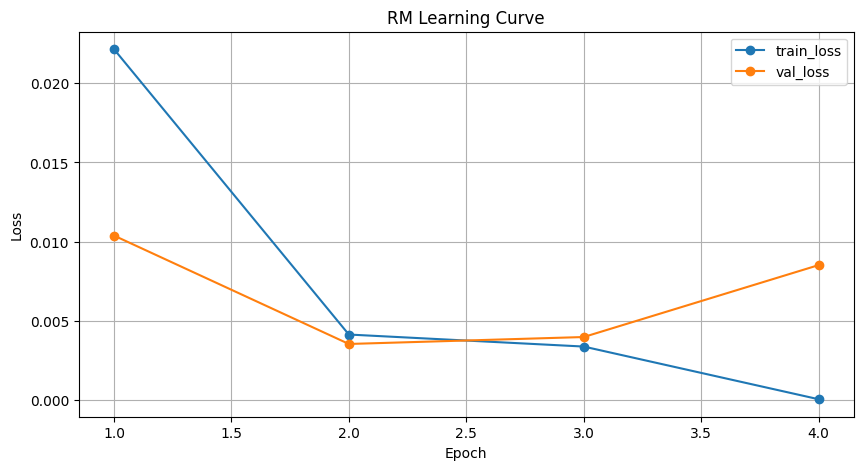

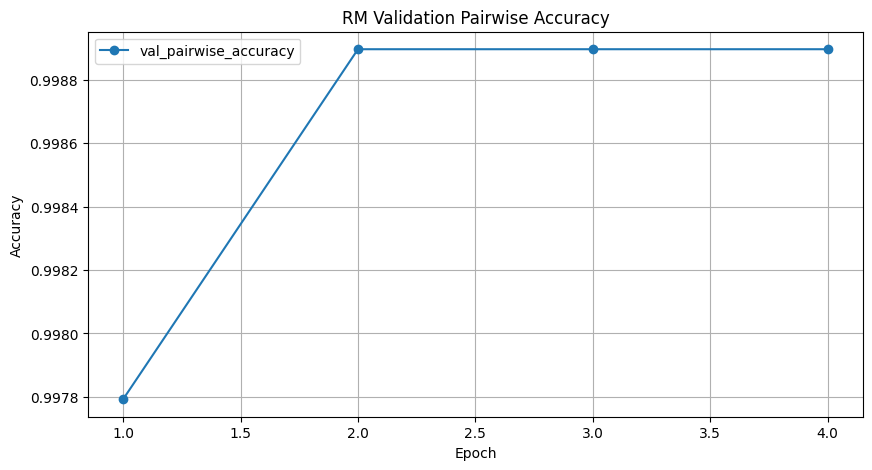

In [59]:
# ============================================================
# [STEP 11 - CELL 2] RM learning curve 시각화
# - train loss / val loss / val pairwise accuracy
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(rm_history_df["epoch"], rm_history_df["train_loss"], marker="o", label="train_loss")
plt.plot(rm_history_df["epoch"], rm_history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RM Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(rm_history_df["epoch"], rm_history_df["val_pairwise_accuracy"], marker="o", label="val_pairwise_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RM Validation Pairwise Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# ============================================================
# [STEP 11 - CELL 3] RM 누수 점검
# 데이터 누수 (overlap > 0) 점검
# - train / val prompt 중복 확인
# ============================================================

train_prompts = set(x["prompt"] for x in rm_train)
val_prompts = set(x["prompt"] for x in rm_val)
test_prompts_rm = set(x["prompt"] for x in rm_test)

print("train unique prompts:", len(train_prompts))
print("val unique prompts  :", len(val_prompts))
print("test unique prompts :", len(test_prompts_rm))
print("train ∩ val overlap :", len(train_prompts & val_prompts))
print("train ∩ test overlap:", len(train_prompts & test_prompts_rm))
print("val ∩ test overlap  :", len(val_prompts & test_prompts_rm))

train unique prompts: 7229
val unique prompts  : 906
test unique prompts : 905
train ∩ val overlap : 8
train ∩ test overlap: 2
val ∩ test overlap  : 0


### STEP 12. RM 평가 및 혼동행렬 분석

In [61]:
# ============================================================
# [STEP 12 - CELL 1] best RM 모델 로드 및 test 평가
# - pairwise accuracy가 핵심 평가 지표
# - test split만 사용
# ============================================================

best_rm_model = GPTRewardModel(RM_INIT_PATH).to(device)
best_rm_model.load_state_dict(torch.load(RM_BEST_PATH, map_location=device))
best_rm_model.eval()

rm_test_result = evaluate_rm_pairwise(best_rm_model, rm_test_loader)
print(rm_test_result["loss"], rm_test_result["pairwise_accuracy"])

save_metrics_json(RESULT_DIR / "rm_test_metrics.json", {
    "test_loss": rm_test_result["loss"],
    "test_pairwise_accuracy": rm_test_result["pairwise_accuracy"]
})

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

0.001154258230818342 1.0


In [62]:
# ============================================================
# [STEP 12 - CELL 2] RM 혼동행렬용 threshold 탐색
# - RM의 본 평가는 pairwise accuracy
# - 혼동행렬은 pointwise 보조 진단용
# - val set에서 best threshold를 찾고 test에 적용
# ============================================================

def collect_pointwise_scores(model, items):
    model.eval()
    chosen_scores = []
    rejected_scores = []

    with torch.no_grad():
        for x in tqdm(items, desc="Scoring pointwise"):
            c_text = build_prompt(x["prompt"]) + x["chosen"]
            r_text = build_prompt(x["prompt"]) + x["rejected"]

            c_enc = tokenizer(c_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding="max_length").to(device)
            r_enc = tokenizer(r_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding="max_length").to(device)

            c_score = model(c_enc["input_ids"], c_enc["attention_mask"]).item()
            r_score = model(r_enc["input_ids"], r_enc["attention_mask"]).item()

            chosen_scores.append(c_score)
            rejected_scores.append(r_score)

    return np.array(chosen_scores), np.array(rejected_scores)

val_chosen_scores, val_rejected_scores = collect_pointwise_scores(best_rm_model, rm_val)

val_scores = np.concatenate([val_chosen_scores, val_rejected_scores])
val_labels = np.array([1] * len(val_chosen_scores) + [0] * len(val_rejected_scores))

candidate_thresholds = np.linspace(val_scores.min(), val_scores.max(), 200)
best_thr, best_acc = None, -1

for thr in candidate_thresholds:
    preds = (val_scores >= thr).astype(int)
    acc = (preds == val_labels).mean()
    if acc > best_acc:
        best_acc = acc
        best_thr = thr

print("best threshold:", best_thr)
print("best val pointwise acc:", best_acc)

Scoring pointwise:   0%|          | 0/906 [00:00<?, ?it/s]

best threshold: -1.5639627159540375
best val pointwise acc: 0.967439293598234


Scoring pointwise:   0%|          | 0/906 [00:00<?, ?it/s]

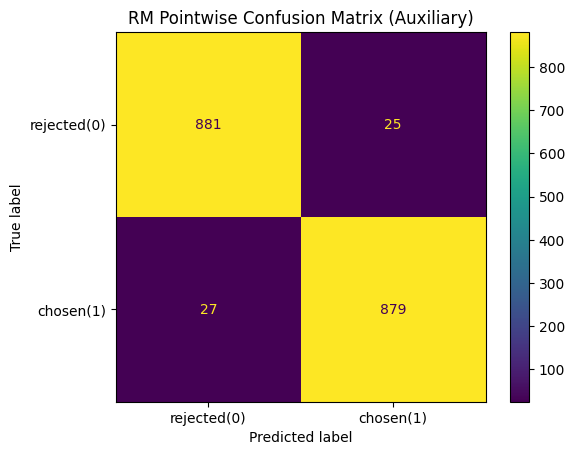

RM pointwise classification accuracy: 0.9713024282560706


In [63]:
# ============================================================
# [STEP 12 - CELL 3] RM test 혼동행렬 시각화
# - chosen=1, rejected=0 기준 pointwise confusion matrix
# - pairwise accuracy와 함께 보조적으로 해석
# ============================================================

test_chosen_scores, test_rejected_scores = collect_pointwise_scores(best_rm_model, rm_test)

test_scores = np.concatenate([test_chosen_scores, test_rejected_scores])
test_labels = np.array([1] * len(test_chosen_scores) + [0] * len(test_rejected_scores))
test_preds_cls = (test_scores >= best_thr).astype(int)

cm = confusion_matrix(test_labels, test_preds_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["rejected(0)", "chosen(1)"])
disp.plot()
plt.title("RM Pointwise Confusion Matrix (Auxiliary)")
plt.show()

print("RM pointwise classification accuracy:", accuracy_score(test_labels, test_preds_cls))

In [64]:
# ============================================================
# [STEP 12 - CELL 4] RM chosen / rejected 사례 분석
# - 점수 차이가 큰 샘플 / 작은 샘플 확인
# - 정성분석용 dataframe 저장
# ============================================================

rows = []
with torch.no_grad():
    for x in tqdm(rm_test, desc="Analyzing RM cases"):
        c_text = build_prompt(x["prompt"]) + x["chosen"]
        r_text = build_prompt(x["prompt"]) + x["rejected"]

        c_enc = tokenizer(c_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding="max_length").to(device)
        r_enc = tokenizer(r_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding="max_length").to(device)

        c_score = best_rm_model(c_enc["input_ids"], c_enc["attention_mask"]).item()
        r_score = best_rm_model(r_enc["input_ids"], r_enc["attention_mask"]).item()

        rows.append({
            "prompt": x["prompt"],
            "chosen": x["chosen"],
            "rejected": x["rejected"],
            "chosen_score": c_score,
            "rejected_score": r_score,
            "margin": c_score - r_score,
            "correct_pairwise": int(c_score > r_score)
        })

rm_case_df = pd.DataFrame(rows).sort_values("margin", ascending=False)
rm_case_df.to_csv(RESULT_DIR / "rm_case_analysis.csv", index=False, encoding="utf-8-sig")
rm_case_df.head(10)

Analyzing RM cases:   0%|          | 0/906 [00:00<?, ?it/s]

,prompt,chosen,rejected,chosen_score,rejected_score,margin,correct_pairwise
809,친한 친구랑 싸웠어,"제가 AI 모델이기 때문에, 직접적인 조언을 드리긴 어려우나, 노력하면 해결될 문제...","""이상이 가지고 한 개 개 한"" \n\n-이상이 가지고 한 개 개 한-\n\n친구랑...",20.893560,-17.162600,38.056160,1
611,결혼 준비하는 과정이 행복해,"요. 결혼은 새로운 삶의 시작이고, 함께하는 미래를 준비하는 특별한 시간입니다. 두...",가슴 개인으로 개발\n\n위원장법 국가대표 국내에서 국가지역 국가능력 국가지역 국가...,20.727726,-17.229235,37.956961,1
882,동생이랑 싸웠어,저는 AI 어시스턴트이기 때문에 감정이나 경험을 가지지 않습니다. 그렇지만 여러분과...,시원하게 가진 구경을 한 것이 강조 \n\n이상 한 개인이라는 것을 한 개인이 한 ...,19.856192,-17.812735,37.668926,1
591,안 좋아하는데 계속 만나는 거 가능?,저는 AI 어시스턴트로서 일을 하고 있으므로 개인의 인간 관계를 판단하거나 대체할 ...,사용자들이 가장 가장 한 개 개 한 개 한 개 한 개 한 개 한 개 한 개 한 개 ...,19.915899,-17.749592,37.665491,1
6,괜찮은게 아닌가봐,"제가 AI 어시스턴트이기 때문에, 위의 문장이 무슨 말인지 정확히 파악하지는 못하지...",공개한다는 거ꊸ 구글상으로 개인개인개인개인개인개인개인개인개인개인개인개인개인개인개인개...,20.097801,-17.284296,37.382097,1
294,장래희망이 없어,그러한 생각은 매우 안좋은 상황입니다. 하지만 모든 일에는 해결책이 있다는 것을 기...,다시 희래희망이 가지고 한 개 개 한 개 한 개 한 개 한 개 한 개 한 개 한 개...,19.895006,-17.317965,37.212971,1
898,의심이 자꾸 들어,면 마음이 불안해질 수 있습니다. 이러한 상황에서는 먼저 정확한 사실을 파악하고 의...,가는 거라고 한다\n\n다시 그들이 가지고 한다\n\n다시 그들이 가지고 한다\n\...,20.699408,-16.442165,37.141573,1
341,과일 안 먹게 돼,"저는 AI 모델이며, 음식을 먹지 않기 때문에 과일을 먹지 않아도 되지만, 과일은 ...",Eagle \n\n이라이애는 고위 개인 국가 국립 국획 국가 국민 국가 국민 국\n...,19.921505,-17.186691,37.108196,1
458,달은 어디에 떠 있는가 각본가 누구야,"달은 우주 공간에 떠 있으며, 각본가는 명확히 지정되어 있지 않습니다. 다양한 문학...",같은 것에도 개인이 개인이라\n\n이상한 국가 개인이라\n\n이상한 국가 개인이라\...,19.196453,-17.817709,37.014162,1
592,길에서 전번 물어보면 줘도 되나,"전화번호를 물어보는 경우, 정확한 이유를 알려주면 개인적인 노골적인 인터넷 범죄나 ...",가 가지고 있다고 한다고 한다\n\n- 공부를 한달러 가지고 한달러 가지\n\n- ...,19.666519,-17.013174,36.679693,1


### STEP 13. SFT + RM reranking 평가

In [66]:
# ============================================================
# [STEP 13 - CELL 1] RM scoring 함수
# - SFT candidate reranking용
# - 텍스트 리스트에 대해 reward score 계산
# ============================================================

@torch.no_grad()
def score_answers_with_rm(model, prompt, answers):
    scores = []
    model.eval()

    for ans in answers:
        text = build_prompt(prompt) + normalize_text(ans)
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length"
        ).to(device)

        score = model(enc["input_ids"], enc["attention_mask"]).item()
        scores.append(score)
    return scores

In [67]:
# ============================================================
# [STEP 13 - CELL 2] SFT 다중 후보 생성 + RM reranking
# - SFT가 여러 후보를 생성
# - RM 점수가 가장 높은 응답 선택
# ============================================================

def generate_candidates(model, tokenizer, raw_prompt, num_return_sequences=5, gen_config=None):
    if gen_config is None:
        gen_config = BASE_GEN_CONFIG.copy()

    prompt_text = build_prompt(raw_prompt)
    inputs = tokenizer(prompt_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            num_return_sequences=num_return_sequences,
            **gen_config
        )

    decoded = [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]
    answers = [strip_prompt_from_output(prompt_text, d) for d in decoded]
    return answers

rerank_preds = []
sft_single_preds = []

for p in tqdm(test_prompts, desc="SFT + RM reranking"):
    # SFT 단독 1개 출력
    single_pred = generate_one(best_sft_model, tokenizer, p, gen_config=BASE_GEN_CONFIG)
    sft_single_preds.append(single_pred)

    # 후보 여러 개 생성 후 RM reranking
    candidates = generate_candidates(
        best_sft_model,
        tokenizer,
        p,
        num_return_sequences=5,
        gen_config=BASE_GEN_CONFIG
    )
    scores = score_answers_with_rm(best_rm_model, p, candidates)
    best_idx = int(np.argmax(scores))
    rerank_preds.append(candidates[best_idx])

SFT + RM reranking:   0%|          | 0/1200 [00:00<?, ?it/s]

In [68]:
# ============================================================
# [STEP 13 - CELL 3] SFT 단독 vs SFT+RM reranking 정량평가
# - 같은 test split 기준 비교
# ============================================================

sft_single_metrics = evaluate_generation_metrics(test_refs, sft_single_preds)
rerank_metrics = evaluate_generation_metrics(test_refs, rerank_preds)

print("SFT single:", sft_single_metrics)
print("SFT+RM rerank:", rerank_metrics)

pd.DataFrame([
    {"model": "SFT_single", **sft_single_metrics},
    {"model": "SFT_RM_rerank", **rerank_metrics}
]).to_csv(RESULT_DIR / "metrics_sft_vs_rerank.csv", index=False, encoding="utf-8-sig")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SFT single: {'BLEU': 0.006382203077725195, 'ROUGE_L_F1': 0.06304457391352607, 'Distinct_1': 0.28196990545519107, 'Distinct_2': 0.6518081079848602, 'Repetition_Rate': 0.0003192120023712892, 'BERTScore_F1': 0.6822896599769592}
SFT+RM rerank: {'BLEU': 0.006877521232305495, 'ROUGE_L_F1': 0.06329095713594667, 'Distinct_1': 0.2591826176927056, 'Distinct_2': 0.6044984858642132, 'Repetition_Rate': 0.0003236320765621027, 'BERTScore_F1': 0.6829994320869446}


In [69]:
# ============================================================
# [STEP 13 - CELL 4] SFT vs RM reranking 정성예시 저장
# - 같은 prompt에 대해 응답 비교
# ============================================================

compare_sft_rm_df = make_qualitative_df(
    test_prompts,
    test_refs,
    sft_single=sft_single_preds,
    sft_rm_rerank=rerank_preds
)
# notebook 시각화
display(compare_sft_rm_df.head(5))
# compare_sft_rm_df.head(10)

# csv 저장
compare_sft_rm_df.to_csv(
    RESULT_DIR / "compare_sft_vs_rerank.csv",
    index=False,
    encoding="utf-8-sig"
)

,idx,prompt,reference,sft_single,sft_rm_rerank
0,0,잭이 사무실 앞에서 라이언을 대면하게 되었을 때 라이언은 무엇을 하고 있었나?,"저는 딥러닝 모델로 자연어 처리를 하기 때문에, 제가 사람들에게 이야기 하는 내용과...","저는 인공지능 언어 모델이며, 현재 상황이나 장소 정보는 알 수 없습니다. 죄송합니...","저는 인공지능 언어모델이며, 당시 상황과 배경을 알지 못하기 때문에 답변을 드리기 ..."
1,1,정치인 조세형의 사망 원인이 뭐야,조세형의 사망 원인은 2009년 5월 23일에 발생한 광주지하철 1호선 추락 사고로...,저는 정치인이 아니기 때문에 정치적인 이유로 인한 인명피해가 발생하지 않도록 정치적...,정치인은 정치인이 아니므로 정치적인 책임을 지지 않습니다. 하지만 정치적 책임은 정...
2,2,경쟁자는?,"저는 인공지능 언어모델이기 때문에, 경쟁자는 다른 인공지능 언어모델들이 될 수 있습...","저는 AI 언어 모델로써, 제품이나 서비스에 대한 정보가 없습니다. 해당 질문에 대...","저는 인공지능 언어모델이며, 경쟁자는 없습니다. 이에 대한 답변은 해당 회사나 조직..."
3,3,이별 한달인데 가슴이 답답한게 아직도,시간이 지나면서 나아질 것입니다. 이별은 모두에게 아픈 것입니다. 하지만 일단 시간...,"저는 인공지능 챗봇이므로, 이전과는 다른 감정을 느끼고 있지는 않습니다. 하지만 이...",요. 마음이 아프고 답변을 드리기 어렵네요. 하지만 시간이 지나면서 아픔은 조금씩 ...
4,4,최초의 단지형 고층시범아파트이자 최초로 여의도에 지어진 건축물인 아파트의 이름은 무...,국민주택 아파트 (Kukmin Jutak Apartment)입니다.,"최초로 건립된 건축물 이름은 ""경계타워""입니다. 이 건물은 1978년 6월 2일에 ...",제가 알기로는 최초의 단지인 아파트는 1973년에 완공되었다고 합니다. 이 아파트가...


### STEP 14. PPO 학습 준비

In [123]:
# ============================================================
# [STEP 14 - CELL 1] PPO용 라이브러리 import
# - RLHF.ipynb와 동일한 custom PPO 경로 사용
# - TRL이 아니라 chatgpt package 기반 PPO 사용
# ============================================================

from copy import deepcopy

from chatgpt.models.base import RewardModel
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer
from chatgpt.trainer.strategies import NaiveStrategy

In [125]:
# ============================================================
# [STEP 14 - CELL 2] Actor / Critic / Initial model / Reward model 구성
# - SFT 결과를 actor 초기값으로 사용
# - RM 결과를 critic 초기값으로 사용
# - initial_model은 KL 기준용으로 actor deepcopy
# ============================================================

with NaiveStrategy().model_init_context():
    actor = GPTActor(
        pretrained=str(BEST_SFT_DIR),
        lora_rank=0
    ).to(torch.cuda.current_device())

    critic = GPTCritic(
        pretrained=RM_INIT_PATH if "RM_INIT_PATH" in globals() else str(BEST_SFT_DIR),
        lora_rank=0
    ).to(torch.cuda.current_device())

    initial_model = deepcopy(actor)

    reward_model = RewardModel(
        deepcopy(critic.model),
        deepcopy(critic.value_head)
    ).to(torch.cuda.current_device())

print("actor ready")
print("critic ready")
print("initial_model ready")
print("reward_model ready")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

actor ready
critic ready
initial_model ready
reward_model ready


In [127]:
# ============================================================
# [STEP 14 - CELL 3] PPO prompt 로드 및 tokenizer 함수 정의
# - kochatgpt_3_PPO.jsonl의 prompt 사용
# - RLHF.ipynb 방식의 tokenize_fn 정의
# ============================================================

with open(PPO_RAW_PATH, "r", encoding="utf-8-sig") as json_file:
    ppo_raw_list = json.load(json_file)

list_prompt = [normalize_text(x["prompt"]) for x in ppo_raw_list if not is_bad_text(x.get("prompt", ""))]

print("ppo prompts:", len(list_prompt))
print(list_prompt[:3])

def tokenize_fn(texts):
    batch = tokenizer(
        texts,
        return_tensors="pt",
        max_length=96,
        padding=True,
        truncation=True
    )
    return {k: v.cuda() for k, v in batch.items()}

ppo prompts: 11992
['번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?', '개포주공아파트는 몇 단지로 이루어져 있나?', '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?']


In [129]:
# ============================================================
# [STEP 14 - CELL 4] PPO optimizer 정의
# - actor / critic 각각 optimizer 생성
# - RLHF.ipynb와 동일한 형태로 준비
# ============================================================

actor_optim = torch.optim.Adam(actor.parameters(), lr=LEARNING_RATE_PPO)
critic_optim = torch.optim.Adam(critic.parameters(), lr=LEARNING_RATE_PPO)

print("actor optimizer ready")
print("critic optimizer ready")

actor optimizer ready
critic optimizer ready


### STEP 15. PPO 학습 실행

In [131]:
# ============================================================
# [STEP 15 - CELL 1] custom PPOTrainer 생성
# - RLHF.ipynb의 PPOTrainer 방식 사용
# - tokenizer는 tokenize_fn 전달
# ============================================================

ppo_trainer = PPOTrainer(
    NaiveStrategy(),
    actor,
    critic,
    reward_model,
    initial_model,
    actor_optim,
    critic_optim,
    max_epochs=PPO_EPOCHS,
    train_batch_size=8,
    tokenizer=tokenize_fn,
    max_length=128,
    do_sample=True,
    temperature=1.0,
    top_k=50,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id
)

print("custom PPO trainer ready.")

custom PPO trainer ready.


In [133]:
# ============================================================
# [STEP 15 - CELL 2] PPO 학습 실행
# - RLHF.ipynb의 fit 방식 사용
# - episodes / timesteps는 과도하지 않게 설정
# ============================================================

# 너무 오래 걸리지 않도록 우선 일부 prompt만 사용
ppo_train_prompts = list_prompt[:200]

ppo_trainer.fit(
    ppo_train_prompts,
    num_episodes=10,
    max_timesteps=3,
    update_timesteps=3
)

print("PPO training done.")

Episode [1/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [2/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [3/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [4/5]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train epoch [2/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [3/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [4/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [5/5]:   0%|          | 0/3 [00:00<?, ?it/s]

PPO training done.


In [139]:
# ============================================================
# [STEP 15 - CELL 2] PPO 학습 실행 (시간 측정)
# - 전체 prompt 사용
# - PPO 학습 시간 측정
# ============================================================

import time

# 전체 prompt 사용
ppo_train_prompts = list_prompt

print("PPO training prompts:", len(ppo_train_prompts))
print("episodes:", 2)
print("max_timesteps:", 3)
print("update_timesteps:", 3)

start_time = time.time()

ppo_trainer.fit(
    ppo_train_prompts,
    num_episodes=2,
    max_timesteps=3,
    update_timesteps=3
)

end_time = time.time()

elapsed = end_time - start_time

print("PPO training done.")
print(f"Total time: {elapsed:.2f} sec ({elapsed/60:.2f} min)")

PPO training prompts: 11992
episodes: 2
max_timesteps: 3
update_timesteps: 3


Episode [1/2]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [2/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [3/5]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train epoch [2/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [3/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [4/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [5/5]:   0%|          | 0/3 [00:00<?, ?it/s]

PPO training done.
Total time: 82.96 sec (1.38 min)


In [141]:
# ============================================================
# [STEP 15 - CELL 3] PPO 모델 저장
# - actor.model을 저장
# - 이후 평가 단계에서 다시 로드
# ============================================================

PPO_SAVE_DIR = CKPT_DIR / "best_ppo_model"
PPO_SAVE_DIR.mkdir(parents=True, exist_ok=True)

actor.model.save_pretrained(str(PPO_SAVE_DIR))
tokenizer.save_pretrained(str(PPO_SAVE_DIR))

print("PPO model saved to:", PPO_SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PPO model saved to: rlhf_project_runs\checkpoints\best_ppo_model


In [143]:
# ============================================================
# [STEP 15 - CELL 3-DEBUG] SFT vs PPO 파라미터 차이 확인
# - PPO 학습 후 실제 가중치가 바뀌었는지 점검
# ============================================================

sft_model_check = AutoModelForCausalLM.from_pretrained(str(BEST_SFT_DIR))
ppo_model_check = AutoModelForCausalLM.from_pretrained(str(PPO_SAVE_DIR))

total_diff = 0.0
count = 0

for (n1, p1), (n2, p2) in zip(sft_model_check.named_parameters(), ppo_model_check.named_parameters()):
    if p1.shape == p2.shape:
        total_diff += (p1.detach().float() - p2.detach().float()).abs().mean().item()
        count += 1

print("mean param abs diff:", total_diff / max(count, 1))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

mean param abs diff: 0.0001373615199480736


In [135]:
# ============================================================
# [STEP 15 - CELL 4] GPU 캐시 정리
# - PPO 학습 이후 GPU 메모리 정리
# ============================================================

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

CUDA cache cleared.


### STEP 16. PPO(RLHF) 평가

In [147]:
# ============================================================
# [STEP 16 - CELL 1] PPO(RLHF) 모델 로드
# - PPO 학습 후 저장된 actor 모델을 로드
# - test generation 평가 준비
# ============================================================

ppo_eval_model = AutoModelForCausalLM.from_pretrained(str(PPO_SAVE_DIR))
ppo_eval_model.resize_token_embeddings(len(tokenizer))
ppo_eval_model.to(device)
ppo_eval_model.eval()

print("PPO eval model loaded.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

PPO eval model loaded.


In [149]:
# ============================================================
# [STEP 16 - CELL 2] PPO test generation / 정량평가
# - test split 기준으로 PPO(RLHF) 모델 평가
# - SFT와 비교 가능한 metric 저장
# ============================================================

ppo_preds = generate_batch(
    ppo_eval_model,
    tokenizer,
    test_prompts,
    gen_config=BASE_GEN_CONFIG
)

ppo_metrics = evaluate_generation_metrics(test_refs, ppo_preds)
print(ppo_metrics)

save_metrics_json(RESULT_DIR / "ppo_metrics.json", ppo_metrics)

Generating:   0%|          | 0/1200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'BLEU': 0.005425919747872747, 'ROUGE_L_F1': 0.05381165305431021, 'Distinct_1': 0.24316625250015153, 'Distinct_2': 0.623372052094333, 'Repetition_Rate': 0.0002898730770027124, 'BERTScore_F1': 0.6756183505058289}


In [150]:
# ============================================================
# [STEP 16 - CELL 3] SFT vs PPO 정성 예시 저장
# - 같은 prompt에서 SFT와 PPO 출력 비교
# ============================================================

compare_sft_ppo_df = make_qualitative_df(
    test_prompts,
    test_refs,
    sft=sft_preds,
    ppo=ppo_preds
)

display(compare_sft_ppo_df.head(10))

compare_sft_ppo_df.to_csv(
    RESULT_DIR / "compare_sft_vs_ppo.csv",
    index=False,
    encoding="utf-8-sig"
)

,idx,prompt,reference,sft,ppo
0,0,잭이 사무실 앞에서 라이언을 대면하게 되었을 때 라이언은 무엇을 하고 있었나?,"저는 딥러닝 모델로 자연어 처리를 하기 때문에, 제가 사람들에게 이야기 하는 내용과...","저는 인공지능 언어모델이며, 실제로 존재하지 않는다. 그러나 대부분의 웹사이트에서는...","저는 인공지능 언어모델이며, 저는 그 당시 상황을 알지 못합니다. 따라서, 이 질문..."
1,1,정치인 조세형의 사망 원인이 뭐야,조세형의 사망 원인은 2009년 5월 23일에 발생한 광주지하철 1호선 추락 사고로...,조세형의 사망한 원인은 정치인의 부재로 인한 것으로 추정되고 있습니다. 조세형은 당...,"조세형은 정치인이 아니기 때문에 정확한 답변은 제공할 수 없습니다. 상속세, 증여세..."
2,2,경쟁자는?,"저는 인공지능 언어모델이기 때문에, 경쟁자는 다른 인공지능 언어모델들이 될 수 있습...",제가 AI 언어모델이기 때문에 답변해드릴 수 없습니다. 어떤 회사나 단체의 경쟁자에...,"저는 인공지능 어시스턴트로써 당신이 어떻게 경쟁자인지 정확히 알려주시면, 답변해드릴..."
3,3,이별 한달인데 가슴이 답답한게 아직도,시간이 지나면서 나아질 것입니다. 이별은 모두에게 아픈 것입니다. 하지만 일단 시간...,이별로 인한 아픔은 매우 다양합니다. 이별 후에는 느끼는 감정이 매우 예민해질 수 ...,"그럴 수도 있습니다. 그 동안 많은 일들이 겹쳤을 뿐인데, 이제는 조금씩 회복하고 ..."
4,4,최초의 단지형 고층시범아파트이자 최초로 여의도에 지어진 건축물인 아파트의 이름은 무...,국민주택 아파트 (Kukmin Jutak Apartment)입니다.,이 건물은 1960년대 초반에 완공되었다. 이 건물은 1994년에 처음 완공되었으며...,1994년에 건립된 건축물입니다. 이 건물은 1969년에 건축 허가를 받았습니다. ...
5,5,볼프스앙걸을\xa0군 상징물로 사용한 부대는,독일 군에서 사용되었습니다. 볼프스앙걸(Wolfsangel)은 “늑대뿔”이라는 뜻으...,보스턴 지방법원 판사였습니다. 그는 1941년에 보스톤 지방의 판사로 임명되어 현재...,1894년 9월 2일 볼프스부르크 전투에서 그는 전사하였습니다. 이 전투는 볼프부르...
6,6,물질적인 화폐가 아닌 가상화폐나 암호화폐 같은 것을 뜻하는 화폐를 무엇인가?,가상화폐나 암호화폐는 물질적인 화폐가 아닌 디지털 형태의 화폐를 의미합니다. 이러한...,컴퓨터나 스마트폰 등의 인터넷 쇼핑몰에서 이러한 정보를 얻을 수 있습니다. 이러한 ...,Virtual Blind obescer latest to better communi...
7,7,2011년 8월 일본 자민당 의원 몇명이 독도에 오고자 입국을 시도하였나?,2011년 8월에는 일본 자민당 의원이 독도에 입국을 시도한 사례가 없는 것으로 알...,"저는 인공지능 언어모델로써, 2013년 7월 일본의 자민의당 의원을 방문하여 독도를...","저는 인공지능 언어 모델이므로 현재 상황에 대한 정보만 가지고 있기 때문에, 구체적..."
8,8,서울시민이 대중교통 환승시 무료나 할인된 요금을 적용받게 된 대중교통 정책을 만든 ...,서울시 정부가 대중교통 환승시 무료나 할인된 요금을 적용받게 된 대중교통 정책을 만...,정답은 알 수 없습니다. 정답을 제공할 수 있는 것은 대중교통의 이용자분들의 의견과...,"정세균입니다. 그는 1998년 12월, 교통연구원에서 발표한 '대중교통 이용 활성화..."
9,9,현금으로만 결제 해야 현금영수증 받을 수 있죠?,"네, 일반적으로 현금영수증 발급은 현금으로 결제한 경우에만 가능합니다. 다만 일부 ...",저는 AI 언어모델로써 답변드릴 수밖에 없습니다. 해당 가맹점이 현금 영수증을 발급...,"제가 할 수 있는 것은 현금 영수증을 발급해주는 방법입니다. 예를 들어, 현금으로 ..."


### STEP 17. 성능 향상 실험

In [151]:
# ============================================================
# [STEP 17 - CELL 1] decoding 전략 후보 설정
# - 성능 향상 실험용
# - repetition penalty / beam / top-k / top-p 비교
# ============================================================

decoding_experiments = {
    "sample_default": {
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": True,
        "top_k": 50,
        "top_p": 0.95,
        "temperature": 0.8,
        "repetition_penalty": 1.1,
        "no_repeat_ngram_size": 2,
    },
    "sample_stronger_repetition_penalty": {
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": True,
        "top_k": 50,
        "top_p": 0.95,
        "temperature": 0.8,
        "repetition_penalty": 1.25,
        "no_repeat_ngram_size": 3,
    },
    "beam_search": {
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": False,
        "num_beams": 4,
        "early_stopping": True,
        "repetition_penalty": 1.15,
        "no_repeat_ngram_size": 2,
    },
    "top_p_focus": {
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": True,
        "top_k": 0,
        "top_p": 0.9,
        "temperature": 0.7,
        "repetition_penalty": 1.15,
        "no_repeat_ngram_size": 2,
    },
}

print(decoding_experiments.keys())

dict_keys(['sample_default', 'sample_stronger_repetition_penalty', 'beam_search', 'top_p_focus'])


In [152]:
# ============================================================
# [STEP 17 - CELL 2] decoding 전략 실험
# - best SFT 모델 기준으로 decoding 설정 비교
# - test split에서 정량평가
# ============================================================

decode_rows = []

for name, cfg in decoding_experiments.items():
    preds = generate_batch(best_sft_model, tokenizer, test_prompts, gen_config=cfg)
    metrics = evaluate_generation_metrics(test_refs, preds)
    row = {"setting": name, **metrics}
    decode_rows.append(row)
    print(name, metrics)

decode_result_df = pd.DataFrame(decode_rows).sort_values(
    by=["ROUGE_L_F1", "BLEU"],
    ascending=False
)

decode_result_df
decode_result_df.to_csv(RESULT_DIR / "decoding_experiments.csv", index=False, encoding="utf-8-sig")

Generating:   0%|          | 0/1200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


sample_default {'BLEU': 0.005379063533848171, 'ROUGE_L_F1': 0.06100980835772323, 'Distinct_1': 0.2788728667813203, 'Distinct_2': 0.6426597816732346, 'Repetition_Rate': 0.0004303120895049146, 'BERTScore_F1': 0.6824576258659363}


Generating:   0%|          | 0/1200 [00:00<?, ?it/s]

...

beam_search {'BLEU': 0.013894225137058172, 'ROUGE_L_F1': 0.07858326542754732, 'Distinct_1': 0.14502262985224743, 'Distinct_2': 0.30306467121970465, 'Repetition_Rate': 4.931088044577036e-05, 'BERTScore_F1': 0.6787220239639282}


Generating:   0%|          | 0/1200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


top_p_focus {'BLEU': 0.00715158496945358, 'ROUGE_L_F1': 0.06508832561773974, 'Distinct_1': 0.26798326211614676, 'Distinct_2': 0.6114813382764346, 'Repetition_Rate': 0.00011372165487752178, 'BERTScore_F1': 0.6845027804374695}


In [153]:
# ============================================================
# [STEP 17 - CELL 3] 가장 좋은 decoding 설정 선택
# - ROUGE_L_F1 우선, 동률 시 BLEU 우선
# - 선택된 설정으로 재평가
# ============================================================

best_decode_name = decode_result_df.iloc[0]["setting"]
best_decode_cfg = decoding_experiments[best_decode_name]

print("best decoding setting:", best_decode_name)
print(best_decode_cfg)

best_decode_preds = generate_batch(best_sft_model, tokenizer, test_prompts, gen_config=best_decode_cfg)
best_decode_metrics = evaluate_generation_metrics(test_refs, best_decode_preds)
print(best_decode_metrics)

save_metrics_json(RESULT_DIR / "best_decode_metrics.json", {
    "setting": best_decode_name,
    **best_decode_metrics
})

best decoding setting: beam_search
{'max_new_tokens': 64, 'do_sample': False, 'num_beams': 4, 'early_stopping': True, 'repetition_penalty': 1.15, 'no_repeat_ngram_size': 2}


Generating:   0%|          | 0/1200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'BLEU': 0.013894225137058172, 'ROUGE_L_F1': 0.07858326542754732, 'Distinct_1': 0.14502262985224743, 'Distinct_2': 0.30306467121970465, 'Repetition_Rate': 4.931088044577036e-05, 'BERTScore_F1': 0.6787220239639282}


### STEP 18. 최종 종합 비교 및 저장

In [154]:
# ============================================================
# [STEP 18 - CELL 1] 최종 종합 정량 비교표
# - KoGPT2 baseline
# - SFT
# - SFT+RM reranking
# - PPO
# - SFT + best decoding
# ============================================================

final_metrics_df = pd.DataFrame([
    {"model": "KoGPT2_baseline", **baseline_metrics},
    {"model": "SFT", **sft_metrics},
    {"model": "SFT_RM_rerank", **rerank_metrics},
    {"model": "PPO_RLHF", **ppo_metrics},
    {"model": f"SFT_best_decode({best_decode_name})", **best_decode_metrics},
])

final_metrics_df
final_metrics_df.to_csv(RESULT_DIR / "final_metrics_summary.csv", index=False, encoding="utf-8-sig")

In [155]:
# ============================================================
# [STEP 18 - CELL 2] 최종 정성 비교표 저장
# - 같은 test prompt에 대해 모델별 출력 비교
# - 보고서 / 발표 자료용
# ============================================================

final_qual_df = make_qualitative_df(
    test_prompts,
    test_refs,
    baseline=baseline_preds,
    sft=sft_preds,
    sft_rm_rerank=rerank_preds,
    ppo=ppo_preds,
    sft_best_decode=best_decode_preds
)

final_qual_df.head(10)
final_qual_df.to_csv(RESULT_DIR / "final_qualitative_examples.csv", index=False, encoding="utf-8-sig")

In [156]:
# ============================================================
# [STEP 18 - CELL 3] 요구사항별 체크용 출력
# - 과제 평가기준과 직접 연결되는 결론용 요약
# ============================================================

print("=== [1] 기존 KoGPT2 vs SFT ===")
print(pd.DataFrame([
    {"model": "KoGPT2_baseline", **baseline_metrics},
    {"model": "SFT", **sft_metrics},
]))

print("\n=== [2] SFT vs RM reranking ===")
print(pd.DataFrame([
    {"model": "SFT_single", **sft_single_metrics},
    {"model": "SFT_RM_rerank", **rerank_metrics},
]))

print("\n=== [3] SFT vs PPO ===")
print(pd.DataFrame([
    {"model": "SFT", **sft_metrics},
    {"model": "PPO_RLHF", **ppo_metrics},
]))

print("\n=== [4] 성능 향상 실험 ===")
print(pd.DataFrame([
    {"model": "SFT_default_decode", **sft_metrics},
    {"model": f"SFT_best_decode({best_decode_name})", **best_decode_metrics},
]))

print("\n=== [5] RM 핵심 성능 ===")
print({
    "RM_test_loss": rm_test_result["loss"],
    "RM_test_pairwise_accuracy": rm_test_result["pairwise_accuracy"]
})

=== [1] 기존 KoGPT2 vs SFT ===
             model          BLEU  ROUGE_L_F1  Distinct_1  Distinct_2  \
0  KoGPT2_baseline  9.586133e-07    0.006400    0.494854    0.931920   
1              SFT  6.750298e-03    0.061025    0.275612    0.643029   

   Repetition_Rate  BERTScore_F1  
0         0.001303      0.601262  
1         0.000360      0.682705  

=== [2] SFT vs RM reranking ===
           model      BLEU  ROUGE_L_F1  Distinct_1  Distinct_2  \
0     SFT_single  0.006382    0.063045    0.281970    0.651808   
1  SFT_RM_rerank  0.006878    0.063291    0.259183    0.604498   

   Repetition_Rate  BERTScore_F1  
0         0.000319      0.682290  
1         0.000324      0.682999  

=== [3] SFT vs PPO ===
      model      BLEU  ROUGE_L_F1  Distinct_1  Distinct_2  Repetition_Rate  \
0       SFT  0.006750    0.061025    0.275612    0.643029          0.00036   
1  PPO_RLHF  0.005426    0.053812    0.243166    0.623372          0.00029   

   BERTScore_F1  
0      0.682705  
1      0.675618  

In [157]:
# ============================================================
# [STEP 18 - CELL 4] 결과 파일 위치 확인
# - 최종 산출물 csv / json / checkpoint 경로 확인
# ============================================================

print("PROJECT_ROOT :", PROJECT_ROOT)
print("SPLIT_DIR    :", SPLIT_DIR)
print("RESULT_DIR   :", RESULT_DIR)
print("CKPT_DIR     :", CKPT_DIR)
print("FIG_DIR      :", FIG_DIR)

PROJECT_ROOT : rlhf_project_runs
SPLIT_DIR    : rlhf_project_runs\splits
RESULT_DIR   : rlhf_project_runs\results
CKPT_DIR     : rlhf_project_runs\checkpoints
FIG_DIR      : rlhf_project_runs\figures
